In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple

%matplotlib inline

In [121]:
df = pd.read_csv('./insurance.csv')

In [122]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [124]:
binary_encoding = {
    'sex': {'female': 0, 'male': 1},
    'smoker': {'no': 0, 'yes': 1}
}

# Using map method for binary encoding
for column, mapping in binary_encoding.items():
    df[column] = df[column].map(mapping)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [125]:
# Encode multi-class categories manually
regions = df['region'].unique()
region_encoding = {region: i for i, region in enumerate(regions)}

# Add one-hot encoding columns
for region in regions:
    df[f'region_{region}'] = (df['region'] == region).astype(int)

# Drop the original 'region' column
df.drop(columns=['region'], inplace=True)

df['b'] = 1

In [126]:
# Standardize numerical features manually
numerical_features = ['age', 'bmi', 'children', 'charges']

for feature in numerical_features:
    mean = df[feature].mean()
    std = df[feature].std()
    df[feature] = (df[feature] - mean) / std

In [127]:
df.head()

,age,sex,bmi,children,smoker,charges,region_southwest,region_southeast,region_northwest,region_northeast,b
0,-1.438227,0,-0.453151,-0.908274,1,0.298472,1,0,0,0,1
1,-1.509401,1,0.509431,-0.078738,0,-0.953333,0,1,0,0,1
2,-0.797655,1,0.383164,1.580335,0,-0.728402,0,1,0,0,1
3,-0.441782,1,-1.305043,-0.908274,0,0.719574,0,0,1,0,1
4,-0.512957,1,-0.292447,-0.908274,0,-0.776512,0,0,1,0,1


In [128]:
# Shuffle the DataFrame
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [129]:
# Define the split ratio
train_ratio = 0.8
split_index = int(len(df) * train_ratio)


In [130]:
# Split the data
df_train = df[:split_index]
df_dev = df[split_index:]


In [131]:
# Separate features and target for training set
X_train = df_train.drop('charges', axis=1)
y_train = df_train['charges']

# Separate features and target for development set
X_dev = df_dev.drop('charges', axis=1)
y_dev = df_dev['charges']


In [132]:
theta = np.zeros(X_train.shape[1])

### Mean Absolute Error (MAE)
The Mean Absolute Error (MAE) is given by:

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

where \( y_i \) is the actual value, \( \hat{y}_i \) is the predicted value, and \( n \) is the number of observations.

### Mean Squared Error (MSE)
The Mean Squared Error (MSE) is given by:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

where \( y_i \) is the actual value, \( \hat{y}_i \) is the predicted value, and \( n \) is the number of observations.

### Root Mean Squared Error (RMSE)
The Root Mean Squared Error (RMSE) is given by:

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

where \( y_i \) is the actual value, \( \hat{y}_i \) is the predicted value, and \( n \) is the number of observations.

### R-squared Score (\( R^2 \))
The R-squared Score (\( R^2 \)) is given by:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

where \( y_i \) is the actual value, \( \hat{y}_i \) is the predicted value, \( \bar{y} \) is the mean of the actual values, and \( n \) is the number of observations.


In [133]:
def r_squared(y: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates the R-squared value for linear regression.

    Parameters:
        y (np.ndarray[float, ndim=1]): The actual target values of shape (m,).
        y_pred (np.ndarray[float, ndim=1]): The predicted target values of shape (m,).

    Returns:
        float: The R-squared value.
    """
    return 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

In [134]:
def mae(y: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates the mean absolute error between the predicted and actual target values.

    Parameters:
        y (np.ndarray[float, ndim=1]): The actual target values of shape (m,).
        y_pred (np.ndarray[float, ndim=1]): The predicted target values of shape (m,).

    Returns:
        float: The mean absolute error.
    """
    return np.mean(np.abs(np.subtract(y, y_pred)))

In [135]:
def mse(y: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates the mean squared error between the predicted and actual target values.

    Parameters:
        y (np.ndarray[float, ndim=1]): The actual target values of shape (m,).
        y_pred (np.ndarray[float, ndim=1]): The predicted target values of shape (m,).

    Returns:
        float: The mean squared error.
    """
    return np.mean(np.square(np.subtract(y, y_pred)))

In [136]:
def rmse(y: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates the root mean squared error between the predicted and actual target values.

    Parameters:
        y (np.ndarray[float, ndim=1]): The actual target values of shape (m,).
        y_pred (np.ndarray[float, ndim=1]): The predicted target values of shape (m,).

    Returns:
        float: The root mean squared error.
    """
    return np.sqrt(mse(y, y_pred))

In [137]:
def predict(X: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """
    Predicts the target values for the given input features.

    Parameters:
        X (np.ndarray[float, ndim=2]): The input features of shape (m, n)
        where m is the number of samples and n is the number of features.
        theta (np.ndarray[float, ndim=1]): The coefficients of shape (n,).

    Returns:
        np.ndarray[float, ndim=1]: The predicted target values of shape (m,).
    """
    predictions: np.ndarray = X.dot(theta) 
    return predictions


In [138]:

def calculate_cost(
    predictions: np.ndarray, y: np.ndarray
) -> float:
    """
    Calculates the cost function for linear regression.

    Parameters:
        X (np.ndarray[float, ndim=2]): The input features of shape (m, n)
        where m is the number of samples and n is the number of features.
        y (np.ndarray[float, ndim=1]): The target values of shape (m,).
        theta (np.ndarray[float, ndim=1]): The coefficients of shape (n,).

    Returns:
        float: The calculated cost value.
    """

    J: float = (1 / 2)  * mse(y, predictions)
    return J

In [139]:
def gradient_descent(
    X: np.ndarray, y: np.ndarray, theta: np.ndarray, alpha: float, num_iters: int
) -> Tuple[np.ndarray, float]:
    """
    Performs gradient descent to minimize the cost function.

    Parameters:
        X (np.ndarray[float, ndim=2]): The input features of shape (m, n)
        where m is the number of samples and n is the number of features.
        y (np.ndarray[float, ndim=1]): The target values of shape (m,).
        theta (np.ndarray[float, ndim=1]): The coefficients of shape (n,).
        alpha (float): The learning rate.
        num_iters (int): The number of iterations to perform gradient descent.

    Returns:
        Tuple[np.ndarray, float]: The updated coefficients and the cost after each iteration.
    """
    m: int = X.shape[0]
    costs = np.zeros(num_iters)

    for i in range(num_iters):
        predictions: np.ndarray = X.dot(theta)
        errors: np.ndarray = np.subtract(predictions, y)
        theta: np.ndarray = theta - alpha * (1 / m) * X.T.dot(errors)
        costs[i] = calculate_cost(predictions, y)
        
    return theta, costs


In [143]:
alpha = 0.001
num_iters = 1000
theta, cost_history = gradient_descent(X_train, y_train, theta, alpha, num_iters)

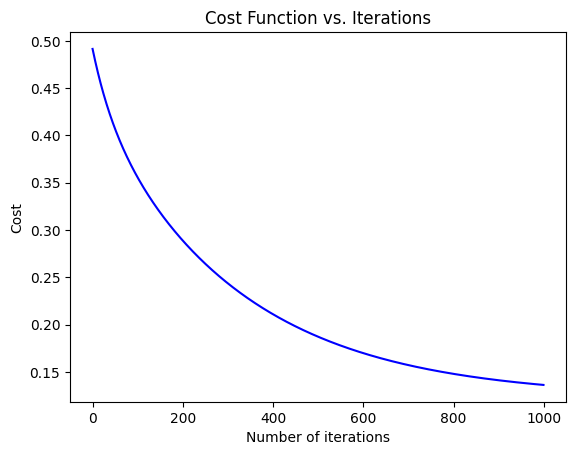

In [141]:
plt.plot(range(1000), cost_history, color='blue')
plt.xlabel('Number of iterations')
plt.ylabel('Cost')
plt.title('Cost Function vs. Iterations')
plt.show()

In [142]:
m = X_dev.shape[0]
predictions = predict(X_dev, theta)
cost = calculate_cost(predictions, y_dev)
print(f"Error: {cost}")

Error: 0.15088424215523535
